## Import library and data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('Merged_Energy_Weather_30min.csv', parse_dates=['Datetime'])
df.head()

,Datetime,Consumption_MW,Forecast_DayMinus1_MW,Forecast_Day_MW,Hour,Minute,DayOfWeek,Month,DayOfYear,IsWeekend,...,Lag_672,Temp_CC,Temp_CE,Temp_CW,Temp_NC,Temp_NE,Temp_NW,Temp_SC,Temp_SE,Temp_SW
0,2018-01-15 00:00:00,66855.0,65200.0,65800.0,0,0,0,1,15,0,...,61127.0,4.266667,1.233333,6.925,2.385714,0.25,6.52,5.771429,6.366667,6.2
1,2018-01-15 00:30:00,65511.0,63600.0,64300.0,0,30,0,1,15,0,...,59962.0,4.266667,1.233333,6.925,2.385714,0.25,6.52,5.771429,6.366667,6.2
2,2018-01-15 01:00:00,63056.0,61500.0,62000.0,1,0,0,1,15,0,...,57879.0,4.266667,1.233333,6.925,2.385714,0.25,6.52,5.771429,6.366667,6.2
3,2018-01-15 01:30:00,62825.0,62400.0,63000.0,1,30,0,1,15,0,...,57901.0,4.266667,1.233333,6.925,2.385714,0.25,6.52,5.771429,6.366667,6.2
4,2018-01-15 02:00:00,62196.0,62300.0,62300.0,2,0,0,1,15,0,...,57261.0,4.266667,1.233333,6.925,2.385714,0.25,6.52,5.771429,6.366667,6.2


In [ ]:
# Set visual style for the report
sns.set_theme(style="whitegrid")
palette = "viridis"

## Graphs

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_ol

--- Quick Stats for your Report ---
Mean Consumption: 52156.10 MW
Max Consumption (Peak): 96272.00 MW
Min Consumption (Off-peak): 29124.00 MW


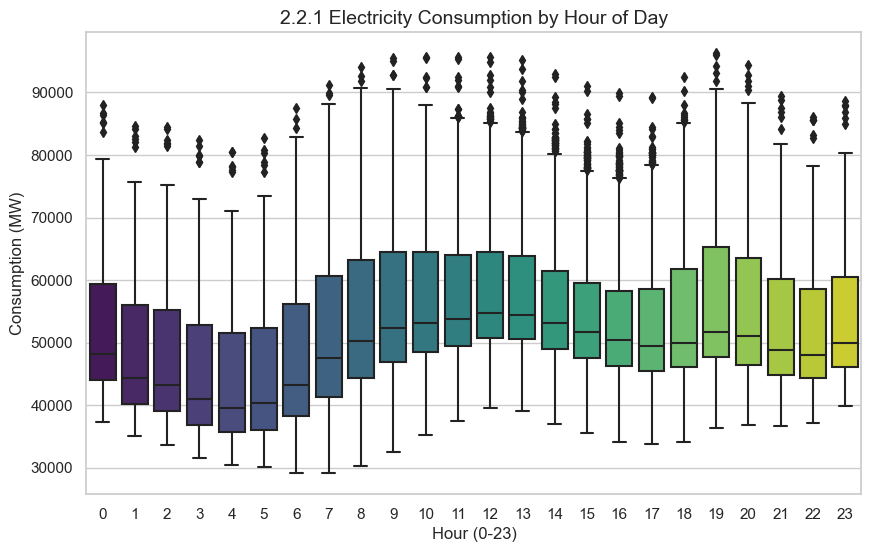

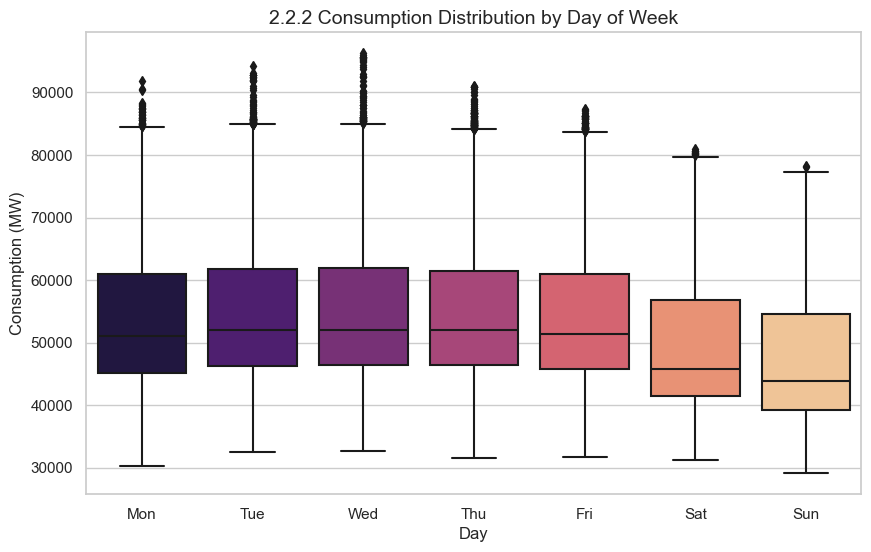

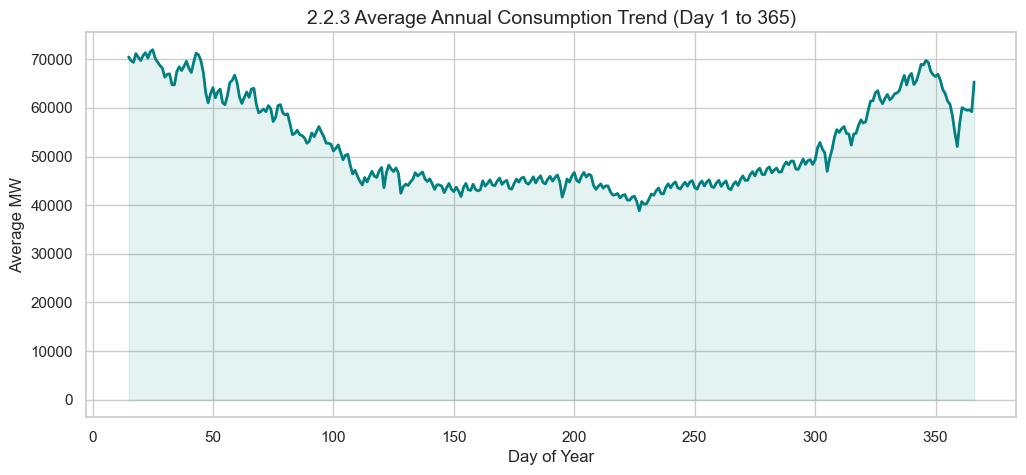

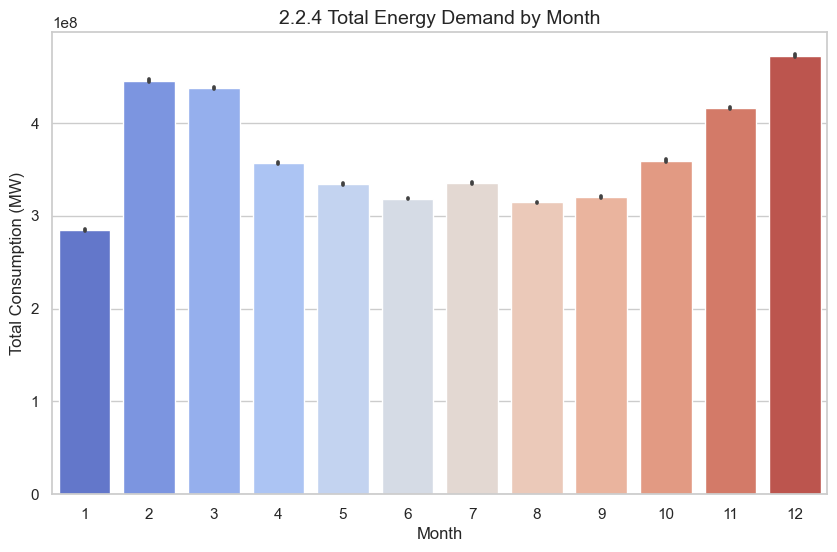

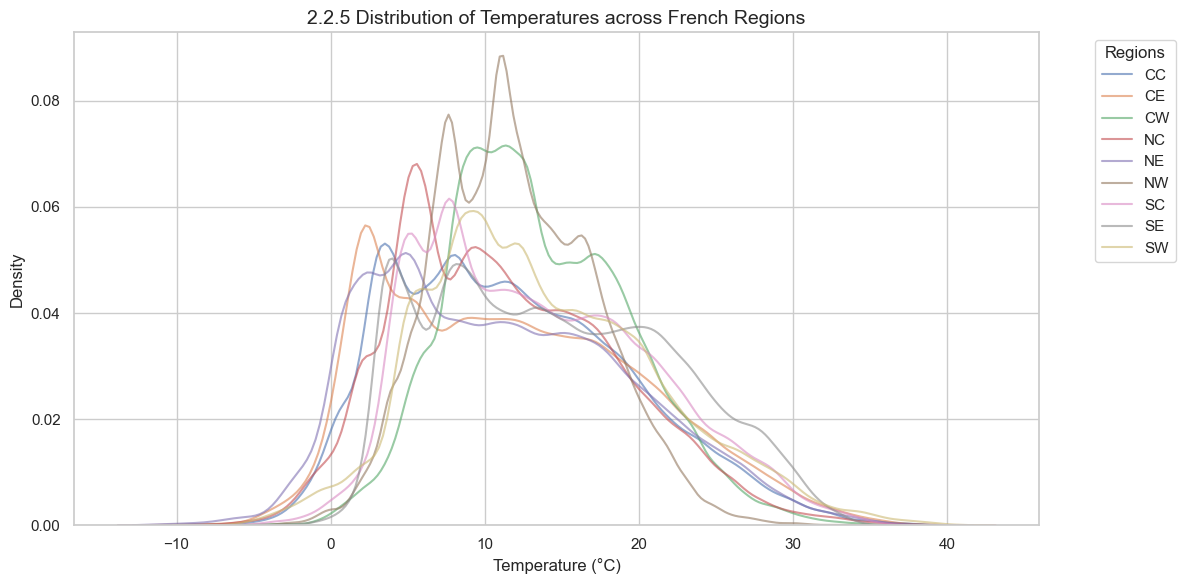

In [16]:
# --- 2.2.1 Hour of the Day Analysis ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Hour', y='Consumption_MW', data=df, palette=palette)
plt.title('2.2.1 Electricity Consumption by Hour of Day', fontsize=14)
plt.ylabel('Consumption (MW)')
plt.xlabel('Hour (0-23)')

# --- 2.2.2 Day of the Week Analysis ---
# Mapping numbers to names for better report readability
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['Day'] = df['DayOfWeek'].map(day_map)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Day', y='Consumption_MW', data=df, 
            order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], palette='magma')
plt.title('2.2.2 Consumption Distribution by Day of Week', fontsize=14)
plt.ylabel('Consumption (MW)')

# --- 2.2.3 Day of the Year Analysis ---
plt.figure(figsize=(12, 5))
daily_avg = df.groupby('DayOfYear')['Consumption_MW'].mean()
plt.plot(daily_avg.index, daily_avg.values, color='teal', linewidth=2)
plt.fill_between(daily_avg.index, daily_avg.values, color='teal', alpha=0.1)
plt.title('2.2.3 Average Annual Consumption Trend (Day 1 to 365)', fontsize=14)
plt.xlabel('Day of Year')
plt.ylabel('Average MW')

# --- 2.2.4 Month of the Year Analysis ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Consumption_MW', data=df, palette='coolwarm', estimator=sum)
plt.title('2.2.4 Total Energy Demand by Month', fontsize=14)
plt.ylabel('Total Consumption (MW)')

# --- 2.2.5 Temperature (Multi-Region Analysis) ---
# We isolate all regional temperature columns
temp_cols = [col for col in df.columns if col.startswith('Temp_')]

plt.figure(figsize=(12, 6))
for col in temp_cols:
    sns.kdeplot(df[col], label=col.replace('Temp_', ''), alpha=0.6)

plt.title('2.2.5 Distribution of Temperatures across French Regions', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# --- Summary Statistics for the 'Analysis' text in the report ---
print("--- Quick Stats for your Report ---")
print(f"Mean Consumption: {df['Consumption_MW'].mean():.2f} MW")
print(f"Max Consumption (Peak): {df['Consumption_MW'].max():.2f} MW")
print(f"Min Consumption (Off-peak): {df['Consumption_MW'].min():.2f} MW")